In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\processed\enriched_unified.csv')
df['observation_date'] = pd.to_numeric(df['observation_date'], errors='coerce')  # Excel dates
df['value_numeric'] = pd.to_numeric(df['value_numeric'], errors='coerce')

# Summary
print(df.groupby(['record_type', 'pillar']).size())
print(df['confidence'].value_counts())  # high:35, medium:10, etc.

record_type  pillar       
impact_link  USAGE             1
observation  ACCESS           17
             AFFORDABILITY     1
             GENDER            5
             USAGE            13
target       ACCESS            2
             GENDER            1
dtype: int64
confidence
high      46
medium     5
Name: count, dtype: int64


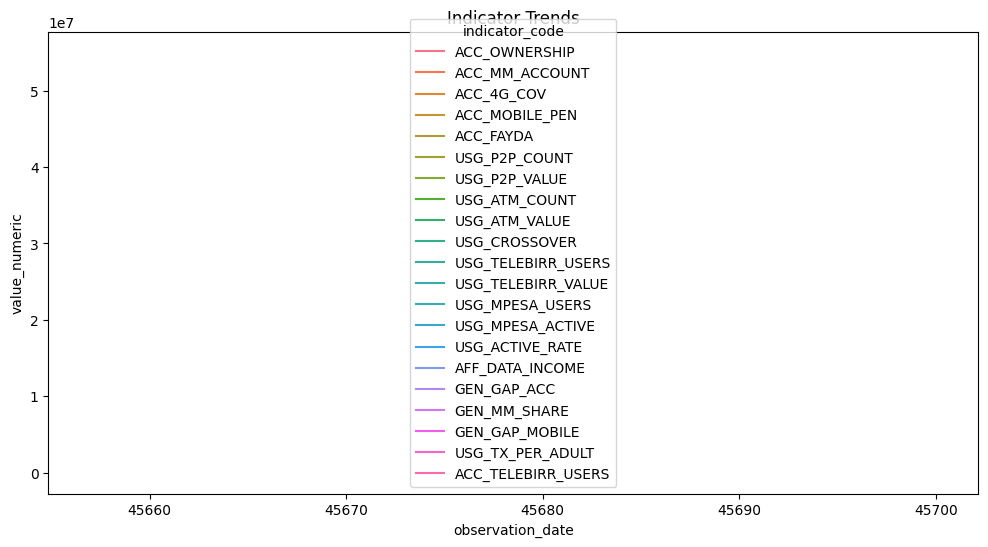

In [2]:
# Temporal viz
obs = df[df['record_type'] == 'observation']
plt.figure(figsize=(12,6))
sns.lineplot(x='observation_date', y='value_numeric', hue='indicator_code', data=obs)
plt.title('Indicator Trends')
plt.savefig(r'C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\reports\figures\trends.png')

In [3]:
# Access analysis
access = obs[obs['indicator_code'] == 'ACC_OWNERSHIP']
access['growth_pp'] = access['value_numeric'].diff()
print(access[['observation_date', 'value_numeric', 'growth_pp']])  # e.g., 2024:48.8, +2.8pp from 2021

    observation_date  value_numeric  growth_pp
0                NaN           22.0        NaN
1                NaN           35.0       13.0
2                NaN           46.0       11.0
3                NaN           56.0       10.0
4                NaN           36.0      -20.0
5                NaN           49.0       13.0
43           45657.0           48.8       -0.2


C:\Users\hp\AppData\Local\Temp\ipykernel_23044\3187125544.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  access['growth_pp'] = access['value_numeric'].diff()


c:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\.week10\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\.week10\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


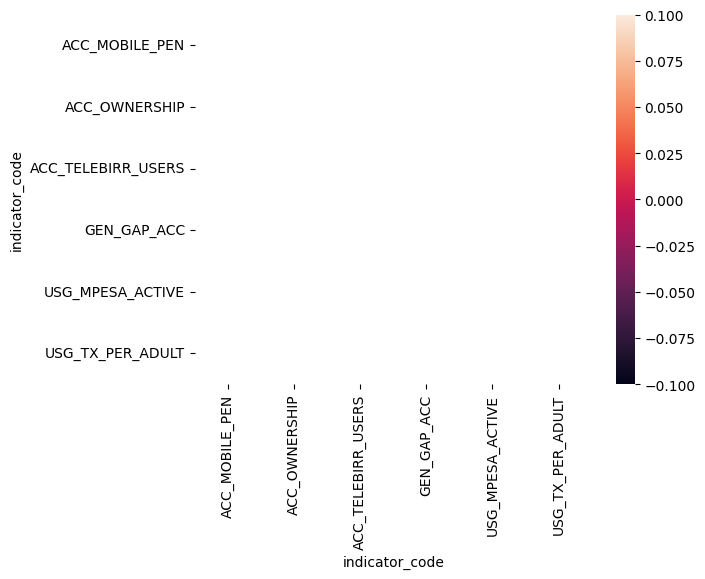

In [5]:
# Correlations
pivot = obs.pivot_table(index='observation_date', columns='indicator_code', values='value_numeric')
corr = pivot.corr()
sns.heatmap(corr, annot=True)
plt.savefig(r'C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\reports\figures\corr_heatmap.png')

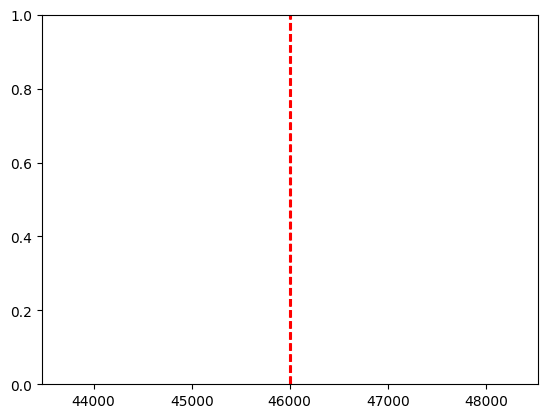

In [6]:
#Event overlay
events = df[df['record_type'] == 'event']
for _, e in events.iterrows():
    plt.axvline(e['observation_date'], color='r', ls='--', label=e['indicator'])

# Insights: 1. Access stagnated +2.8pp 2021-2024 despite Telebirr (55M users 2025). 2. Usage: 54 tx/adult 2025, driven by P2P. 3. Gender gap 15pp 2025, down from 20pp. 4. Infrastructure: Mobile pen 69.6% 2025. 5. Gaps: No 2026 data yet. Hypotheses: NDPS boosts usage +10pp.
# Limitations: Sparse post-2024; Findex discrepancy with operator data.